# Centralized RAG(Retrieval-Augmented Generation) with MergerRetriever using:

- Document chunking for embeddings.  
- Embedding model selection.  
- Composite retrieval with LangChain.   

To enhance retrieval accuracy & reducing hallucinations in Question Answering Chatbot tasks.

In [ ]:
# Install required packages
!pip install -qqq langchain faiss-cpu python-dotenv
!pip install -qqq -U langchain-openai
!pip install -qqq langchain-core langchain-openai langchain-community beautifulsoup4 requests
!pip install -qqq sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/12

In [ ]:
import os
import sys
from bs4 import BeautifulSoup
import string
import requests
from urllib.parse import urljoin, urlparse
from langchain.document_loaders import WebBaseLoader
from langchain.text_splitter import CharacterTextSplitter
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain.docstore.document import Document
from langchain.chains import RetrievalQA
from langchain.retrievers import MergerRetriever
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

In [ ]:
# Set OpenAI API key
os.environ["OPENAI_API_KEY"] = "sk-xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"

In [ ]:
def clean_html(raw_html: str) -> str:
    # Text cleaning (Remove boilerplate HTML tags like script, style, nav, footer, header)
    soup = BeautifulSoup(raw_html, "html.parser")
    for tag in soup(["script", "style", "nav", "footer", "header"]):
        tag.decompose()
    text = soup.get_text(separator="\n")
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    return "\n".join(lines)

def chunk_documents(docs, chunk_size=1100, chunk_overlap=200):
    #Split each LangChain Document into smaller chunks for embeddings.
    splitter = CharacterTextSplitter(
        separator="\n",
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )
    chunks = []
    for doc in docs:
        # Split page_contents
        pieces = splitter.split_text(doc.page_content)
        for piece in pieces:
            chunks.append(Document(page_content=piece, metadata=doc.metadata))
    return chunks

In [ ]:
#Web scraper that supports recursive crawling with depth control.

def scrape_website(url, max_depth=2):
    visited = set()
    documents = []
    domain = urlparse(url).netloc

    def scrape(current_url, depth):
        if depth > max_depth or current_url in visited:
            return

        visited.add(current_url)
        print(f"Scraping (depth {depth}): {current_url}", file=sys.stderr)

        try:
            # Use a realistic user agent
            headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
            response = requests.get(current_url, timeout=10, headers=headers)
            response.encoding = response.apparent_encoding  # Fix encoding issues
            response.raise_for_status()

            content = clean_html(response.text) # Clean HTML

            # Create document with metadata
            doc = Document(
                page_content=content,
                metadata={"source": current_url, "title": current_url.split("/")[-1]}
            )
            documents.append(doc)

            # Only follow links if not at max depth
            if depth < max_depth:
                soup = BeautifulSoup(response.text, "html.parser")
                for link in soup.find_all("a", href=True):
                    href = link["href"]
                    full_url = urljoin(current_url, href)

                    # Only follow links within the same domain
                    if urlparse(full_url).netloc == domain and full_url not in visited:
                        scrape(full_url, depth + 1)

        except Exception as e:
            print(f"Error scraping {current_url}: {e}", file=sys.stderr)

    # Start scraping from the initial URL
    scrape(url, 0)
    print(f"Scraped {len(documents)} pages from {url}", file=sys.stderr)
    return documents

def get_federated_docs(urls, max_depth=2):
    """
    Crawl a list of URLs up to max_depth and return a list of LangChain Document objects.
    """
    all_docs = []
    for url in urls:
        docs = scrape_website(url, max_depth=max_depth)
        all_docs.extend(docs)
    return all_docs

In [ ]:
# Initialize embedding model
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# Define URLs for Hull and Keele
hull_urls = [
    "https://online.hull.ac.uk",
    "https://online.hull.ac.uk/contact",
    "https://online.hull.ac.uk/why-join-us/faqs",
    "https://online.hull.ac.uk/funding-options",
    "https://online.hull.ac.uk/course-costs"
]

keele_urls = [
    "https://online.keele.ac.uk/online-programme/msc-computer-science-with-artificial-intelligence",
    "https://online.keele.ac.uk/online-study",
    "https://online.keele.ac.uk/about-us"
]

# Load, clean, and chunk documents
print("Loading and processing Hull documents...")
hull_raw = get_federated_docs(hull_urls, max_depth=1)
hull_chunks = chunk_documents(hull_raw)
print(f" - {len(hull_chunks)} Hull chunks created.")

print("Loading and processing Keele documents...")
keele_raw = get_federated_docs(keele_urls, max_depth=1)
keele_chunks = chunk_documents(keele_raw)
print(f" - {len(keele_chunks)} Keele chunks created.")

# Build FAISS indexes
print("Building FAISS index for Hull...")
hull_index = FAISS.from_documents(hull_chunks, embeddings)
print("Building FAISS index for Keele...")
keele_index = FAISS.from_documents(keele_chunks, embeddings)

Loading and processing Hull documents...


Scraping (depth 0): https://online.hull.ac.uk
Scraping (depth 1): https://online.hull.ac.uk/#main
Scraping (depth 1): https://online.hull.ac.uk/contact
Scraping (depth 1): https://online.hull.ac.uk/
Scraping (depth 1): https://online.hull.ac.uk/why-join-us/how-you-learn
Scraping (depth 1): https://online.hull.ac.uk/why-join-us/online-student-experience
Scraping (depth 1): https://online.hull.ac.uk/student-experience/testimonials
Scraping (depth 1): https://online.hull.ac.uk/events
Scraping (depth 1): https://online.hull.ac.uk/student-experience/graduation
Scraping (depth 1): https://online.hull.ac.uk/why-join-us/faqs
Scraping (depth 1): https://online.hull.ac.uk/blog
Scraping (depth 1): https://online.hull.ac.uk/courses
Scraping (depth 1): https://online.hull.ac.uk/courses/msc-artificial-intelligence
Scraping (depth 1): https://online.hull.ac.uk/courses/ma-creative-writing
Scraping (depth 1): https://online.hull.ac.uk/courses/msc-dementia
Scraping (depth 1): https://online.hull.ac.uk/c

 - 1660 Hull chunks created.
Loading and processing Keele documents...


Scraping (depth 1): https://online.keele.ac.uk/request-information/
Scraping (depth 1): https://online.keele.ac.uk/
Scraping (depth 1): https://online.keele.ac.uk/online-programmes/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-computer-science-with-artificial-intelligence#programme
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-with-marketing/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-with-sustainability/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-with-data-analytics/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-hr/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-healthcare/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-project/
Scraping (depth 1): https://online.keele.ac.uk/online-pro

 - 1178 Keele chunks created.
Building FAISS index for Hull...
Building FAISS index for Keele...


In [ ]:
# cross-encoder for re-ranking
reranker = SentenceTransformer("all-mpnet-base-v2")

def rerank(query, candidate_docs, top_n=5):
    # Re-rank candidate_docs (LangChain Documents) using a sentence-transformers cross-encoder.
    query_emb = reranker.encode(query, convert_to_tensor=True)
    texts = [d.page_content for d in candidate_docs]
    doc_embs = reranker.encode(texts, convert_to_tensor=True)
    scores = util.cos_sim(query_emb, doc_embs)[0]
    top_idxs = scores.topk(k=top_n).indices.cpu().numpy()
    return [candidate_docs[i] for i in top_idxs]

# Build separate retrievers
hull_retriever = hull_index.as_retriever(search_kwargs={"k": 10})
keele_retriever = keele_index.as_retriever(search_kwargs={"k": 10})

# Composite retriever using MergerRetriever
# It's okay for Federated RAG to merge retrievers, as long as no raw data leaves the local sources. It doesn't mean merging real datas.
# Each *.as_retriever() only accesses its own private index (hull_index, keele_index).
# The MergerRetriever acts like a meta-retriever combining the outputs (e.g., passages) without accessing the private corpora.
combined_retriever = MergerRetriever(retrievers=[hull_retriever, keele_retriever])

# Build RetrievalQA chain
qa_chain = RetrievalQA.from_chain_type(
    llm=ChatOpenAI(model_name="gpt-4o", temperature=0, max_tokens=256),
    retriever=combined_retriever,
    return_source_documents=False,
    chain_type="stuff",)

def query(question):
    # Run the RetrievalQA chain and return the answer.
    res = qa_chain({"query": question})
    return res["result"].strip()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def normalize(text: str) -> list:

    # Lowercase, strip punctuation, commas, and currency symbols, then split into tokens
    t = text.lower().replace(",", "").replace("£", "").replace("pounds", "")
    translator = str.maketrans("", "", string.punctuation)
    return t.translate(translator).split()

def exact_match(prediction: str, truth: str) -> int:
    # Return 1 if normalized truth matches normalized prediction exactly or as a subset.
    npred = normalize(prediction)
    ntruth = normalize(truth)
    if ntruth == npred or set(ntruth).issubset(set(npred)):
        return 1
    return 0

def f1_score(prediction: str, truth: str) -> float:
    # Calculate F1 score between prediction and ground truth.
    pred_tokens = normalize(prediction)
    truth_tokens = normalize(truth)

    common = set(pred_tokens) & set(truth_tokens)
    if not common:
        return 0.0

    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(truth_tokens)

    if precision + recall == 0:
        return 0.0

    return 2 * (precision * recall) / (precision + recall)

In [ ]:
# Define evaluation questions and corresponding ground truth answers
questions = [
    "What is the total cost of the MSc Artificial Intelligence online programme at the University of Hull?",
    "How long does the MSc Artificial Intelligence online programme at the University of Hull take to complete?",
    "What is the phone number for enquiries about online courses at the University of Hull?",
    "What is the email address for enquiries about online courses at the University of Hull?",
    "When are the start dates for the MSc Artificial Intelligence online programme at the University of Hull?",
    "How much is the acceptance fee required to secure a place for Hull online courses, and how is it applied to the tuition fees?",
    "What are the minimum academic entry requirements for applicants holding a degree for the Hull MSc AI programme?",
    "What is the credit for each module in the University of Hull MSc Artificial Intelligence programme?",
    "What is the alumni tuition fee discount offered by Keele University for this online MSc programme, and what is the reduced total fee?",
    "How many times per year can students start the Keele online MSc Computer Science with Artificial Intelligence programme?",
    "Would an IELTS overall score of 6.0 meet the English language requirements for the online MSc Computer Science with Artificial Intelligence at Keele University?",
    "What is the total programme fee for the online MSc Computer Science with Artificial Intelligence at Keele University?",
    "How long does the online MSc Computer Science with Artificial Intelligence at Keele University take to complete?",
    "What is the email address for enquiries about online programmes at Keele University?",
    "How many credits are required to complete the online MSc Computer Science with Artificial Intelligence at Keele University?"
]

# Correct answers based on context
ground_truths = [
    "The total cost of the MSc Artificial Intelligence online programme at the University of Hull is £8,950",
    "The MSc Artificial Intelligence online programme at the University of Hull takes 24 months (two years) to complete on a part-time basis",
    "The phone number for enquiries about online courses at the University of Hull is +44 (0)1482 251819",
    "The email address for enquiries about online courses at the University of Hull is enquiries-online@hull.ac.uk",
    "The start dates of the MSc Artificial Intelligence online programme at the University of Hull are January, May, and September. The next start date is 22 September 2025.",
    "At the University of Hull, The acceptance fee required to secure a place for Hull online courses is £350. This fee must be paid within two weeks of the date on your offer letter.",
    "For the University of Hull MSc AI programme, Applicants holding a degree should have or be about to complete a minimum 2:2 undergraduate degree",
    "Each module in the MSc Artificial Intelligence online programme at the University of Hull is worth 630 credits",
    "Keele University offers a 10% alumni tuition fee discount on this online MSc programme, reducing the total fee to £6,696",
    "Students can start the Keele University online MSc Computer Science with Artificial Intelligence programme six times per year",
    "Yes. Keele University requires an IELTS overall score of 6.0 with no component below 5.5 meets the programme's English language requirement.",
    "The total programme fee for the online MSc Computer Science with Artificial Intelligence at Keele University is £7,440",
    "The online MSc Computer Science with Artificial Intelligence at Keele University is designed to be completed in 24 months (two years) part-time",
    "The email address for enquiries about online programmes at Keele University is enrolments@online.keele.ac.uk",
    "The online MSc Computer Science with Artificial Intelligence at Keele University is a 180-credit programme"
]

In [ ]:
# Run evaluation
predictions = []
em_scores = []
f1_scores = []

# Make sure we only iterate up to the minimum length of both lists to avoid IndexError
min_length = min(len(questions), len(ground_truths))

for i in range(min_length):
    print(f"Question {i+1}: {questions[i]}")
    answer = query(questions[i])
    predictions.append(answer)
    print(f"Prediction: {answer}")
    print(f"Ground Truth: {ground_truths[i]}")

    em = exact_match(answer, ground_truths[i])
    f1 = f1_score(answer, ground_truths[i])
    em_scores.append(em)
    f1_scores.append(f1)

    print(f"Exact Match: {em}, F1 Score: {f1:.2f}\n")

# Calculate average scores
avg_em = sum(em_scores) / len(em_scores)
avg_f1 = sum(f1_scores) / len(f1_scores)

print(f"Average Exact Match: {avg_em:.2f}")
print(f"Average F1 Score: {avg_f1:.2f}")

Question 1: What is the total cost of the MSc Artificial Intelligence online programme at the University of Hull?


/tmp/ipython-input-13-4046389418.py:32: LangChainDeprecationWarning: The method `Chain.__call__` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  res = qa_chain({"query": question})


Prediction: The total cost of the MSc Artificial Intelligence online programme at the University of Hull is £8,950.
Ground Truth: The total cost of the MSc Artificial Intelligence online programme at the University of Hull is £8,950
Exact Match: 1, F1 Score: 0.82

Question 2: How long does the MSc Artificial Intelligence online programme at the University of Hull take to complete?
Prediction: The MSc Artificial Intelligence online programme at the University of Hull takes two years to complete on a part-time basis.
Ground Truth: The MSc Artificial Intelligence online programme at the University of Hull takes 24 months (two years) to complete on a part-time basis
Exact Match: 0, F1 Score: 0.90

Question 3: What is the phone number for enquiries about online courses at the University of Hull?
Prediction: The phone number for enquiries about online courses at the University of Hull is +44 (0)1482 251819.
Ground Truth: The phone number for enquiries about online courses at the University o

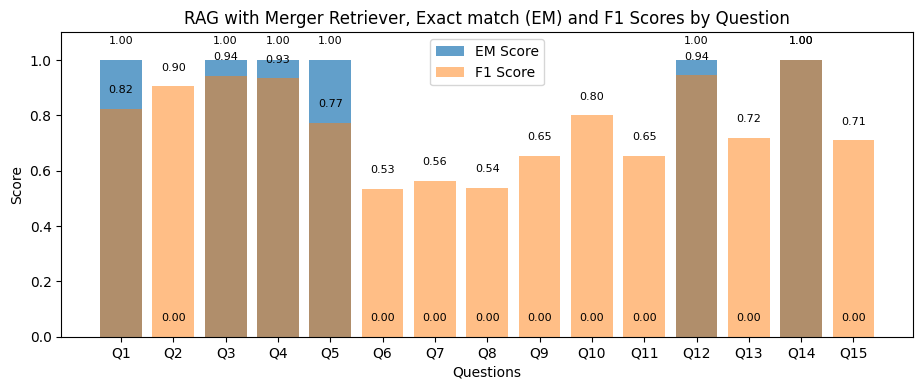

In [ ]:
# Visualize results2
plt.figure(figsize=(18, 4))

# Plot individual scores
plt.subplot(1, 2, 1)
question_ids = [f"Q{i+1}" for i in range(len(em_scores))]
bars1 = plt.bar(question_ids, em_scores, alpha=0.7, label='EM Score')
bars2 = plt.bar(question_ids, f1_scores, alpha=0.5, label='F1 Score')
plt.ylim(0, 1.1)
plt.xlabel('Questions')
plt.ylabel('Score')
plt.title('RAG with Merger Retriever, Exact match (EM) and F1 Scores by Question')
plt.legend()

# Add score values above each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.05,
                                 f'{height:.2f}', ha='center', va='bottom', fontsize=8)


plt.tight_layout()
plt.savefig('RAG with Merger Retriever_by_question.jpg', format='jpg', dpi=300) # Save as JPEG
plt.show()

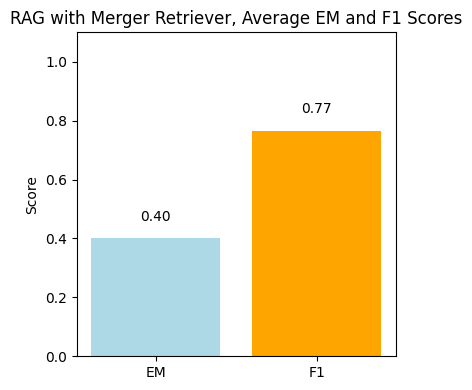

In [ ]:
#Plot average EM & F1 in a separate square figure
plt.figure(figsize=(4, 4))
bars3 = plt.bar(['EM', 'F1'], [avg_em, avg_f1], color=['lightblue', 'orange'])
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('RAG with Merger Retriever, Average EM and F1 Scores')
for bar in bars3:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + .05, f'{h:.2f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig('RAG with Merger Retriever_em_f1_average.jpg', format='jpg', dpi=300) # Save as JPEG
plt.show()